In [5]:
# Part 1 — Problem Definition & Dataset Verification
# Task 1 Description: Load clean_churn.csv (or re-run Lab 2 cleaning) and verify its shape and dtypes.

import pandas as pd, numpy as np

df = pd.read_csv('clean_churn.csv')

print(df.shape)
df.info()
print(df.isnull().sum().sum())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [6]:
# Task2 Restate Lab 3's Decision Tree and Lab 4's Random Forest test-set results — these are today's benchmarks.
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y = df['Churn'].map({'No': 0, 'Yes': 1})
X = df.drop(columns=['Churn', 'customerID'])
cat_cols = X.select_dtypes(include='object').columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

dt = DecisionTreeClassifier(max_depth=6, criterion='entropy', random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1:", f1_score(y_test, dt_pred))

Accuracy: 0.794180269694819
Precision: 0.6193181818181818
Recall: 0.5828877005347594
F1: 0.6005509641873278


In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print("RF Precision:", precision_score(y_test, rf_pred))
print("RF Recall:", recall_score(y_test, rf_pred))
print("RF F1:", f1_score(y_test, rf_pred))

RF Accuracy: 0.7927608232789212
RF Precision: 0.6366666666666667
RF Recall: 0.5106951871657754
RF F1: 0.5667655786350149


In [8]:
# Lab 3's Decision Tree (depth=6, entropy) scored 79.4% accuracy, 61.9% precision, 58.3% recall, F1=0.601. Lab 4's default Random Forest scored 79.3% accuracy, 63.7% precision, 51.1% recall, F1=0.567; tuned RF scored 79.7% accuracy, 65.1% precision, 50.8% recall, F1=0.571. The Decision Tree slightly outperformed both on F1.

In [9]:
# Part 2 — Feature Scaling & Preparation
# Task 3 Prepare X and y exactly as in Lab 3/4 (encode categoricals, drop identifiers, target as 0/1).
y = df['Churn'].map({'No': 0, 'Yes': 1})
X = df.drop(columns=['Churn', 'customerID'])

cat_cols = X.select_dtypes(include='object').columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

print(X.shape)
print(X.isnull().sum().sum())

(7043, 30)
0


In [10]:
# Task 4 In 2–3 sentences, explain why feature scaling matters for KNN and Logistic Regression but wasn't necessary for the Decision Tree or Random Forest.
# KNN measures distance between points — a large-scale feature (like MonthlyCharges) would dominate a small-scale one (like tenure) without scaling. Logistic Regression also trains faster/better with scaled features. Decision Trees/Random Forests split each feature independently using thresholds, so raw scale never affects their splits.

In [11]:
# Task 5 KNN measures distance between points — a large-scale feature (like MonthlyCharges) would dominate a small-scale one (like tenure) without scaling. Logistic Regression also trains faster/better with scaled features. Decision Trees/Random Forests split each feature independently using thresholds, so raw scale never affects their splits.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled = scaler.transform(X_test)          # only transform on test

print(X_train_scaled.shape, X_test_scaled.shape)
print(X_train_scaled[:2])  # peek at scaled values

(5634, 30) (1409, 30)
[[-0.44177295  0.10237124 -0.52197565 -0.2622572   0.99433624 -0.96923413
  -0.65155653 -3.01309011  3.01309011 -0.85833837 -0.88769579 -0.52408075
  -0.52408075 -0.63611103 -0.52408075 -0.73554636 -0.52408075  1.37557156
  -0.52408075 -0.64327425 -0.52408075  1.25216312 -0.52408075  1.24796703
  -0.51278214 -0.56382155 -1.20265302 -0.52380561  1.40690298 -0.54384572]
 [-0.44177295 -0.71174346  0.33747781 -0.50363479  0.99433624  1.03174245
   1.53478624  0.3318852  -0.3318852  -0.85833837  1.12651205 -0.52408075
  -0.52408075  1.57205259 -0.52408075 -0.73554636 -0.52408075 -0.72697054
  -0.52408075 -0.64327425 -0.52408075 -0.79861799 -0.52408075 -0.80130322
  -0.51278214 -0.56382155 -1.20265302 -0.52380561 -0.71078107  1.83875676]]


In [12]:
# Scaler is fit only on training data because fitting on the full dataset (train+test) would leak test-set information into the scaling, artificially inflating test performance — a form of data leakage.


In [37]:
# Part 3 — Logistic Regression
# Task 6 Train a LogisticRegression model on the scaled training data. Generate predictions on the scaled test set.
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train)
logreg_pred = logreg.predict(X_test_scaled)

Accuracy:  0.8069552874378992
Precision: 0.6583850931677019
Recall:    0.5668449197860963
F1-score:  0.6091954022988506
[[925 110]
 [162 212]]


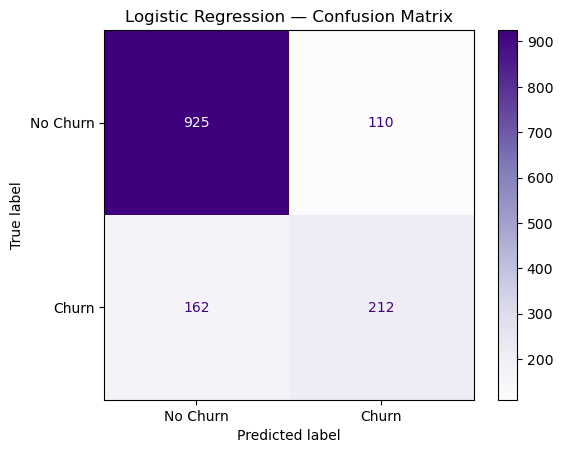

In [34]:
# Trained Logistic Regression on scaled training data, predicted on scaled test data — scaling matters here since it affects the optimization, unlike the tree-based models in Labs 3-4.


# Task 7 Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

print("Accuracy: ", accuracy_score(y_test, logreg_pred))
print("Precision:", precision_score(y_test, logreg_pred))
print("Recall:   ", recall_score(y_test, logreg_pred))
print("F1-score: ", f1_score(y_test, logreg_pred))

cm_logreg = confusion_matrix(y_test, logreg_pred)
print(cm_logreg)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Purples')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

In [16]:
   # Logistic Regression achieved 80.7% accuracy, 65.8% precision, 56.7% recall, F1=0.609 — 
   # the confusion matrix shows it caught 212 of 374 actual churners while keeping false alarms 
   # relatively low (110).


# Task 8 Look at predict_proba for a handful of test customers. In 1-2 sentences, explain what these probabilities represent and how predict() turns them into a Yes/No decision.
probs = logreg.predict_proba(X_test_scaled)

# show probabilities for first 10 test customers
prob_df = pd.DataFrame({
    'Prob_No_Churn': probs[:10, 0],
    'Prob_Yes_Churn': probs[:10, 1],
    'Predicted': logreg_pred[:10]
})
print(prob_df)

   Prob_No_Churn  Prob_Yes_Churn  Predicted
0       0.955018        0.044982          0
1       0.316766        0.683234          1
2       0.943458        0.056542          0
3       0.592194        0.407806          0
4       0.978334        0.021666          0
5       0.396462        0.603538          1
6       0.548127        0.451873          0
7       0.869075        0.130925          0
8       0.997148        0.002852          0
9       0.605855        0.394145          0


In [17]:
# Each row shows the probability the model assigns to "No Churn" and "Yes Churn" for that customer — the two always sum to 1.0. .predict() applies a 0.5 threshold: if Prob_Yes_Churn is above 0.5, it predicts 1 (Yes/Churn); otherwise it predicts 0 (No/Churn).

In [20]:
# Part 4 — KNN & Choosing K 
# Task 9 Train KNN classifiers for several values of K (e.g. 1, 3, 5, 7, 9, 11, 15, 21) on the scaled data. Record test-set 
# accuracy and F1-score for each K in a results table. 

import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'  # set based on your machine's core count

from sklearn.neighbors import KNeighborsClassifier

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    knn_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, knn_pred)
    f1 = f1_score(y_test, knn_pred)
    results.append({'K': k, 'Accuracy': acc, 'F1-score': f1})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 K  Accuracy  F1-score
 1  0.716111  0.476440
 3  0.743790  0.512821
 5  0.747339  0.512329
 7  0.759404  0.532414
 9  0.769340  0.557823
11  0.772889  0.561644
15  0.770050  0.554945
21  0.770759  0.561737


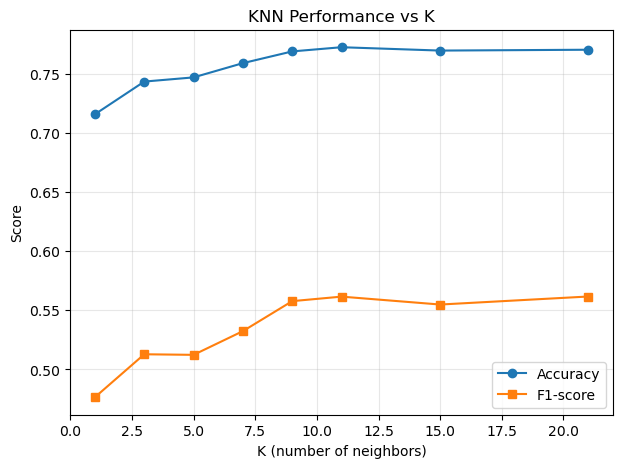

In [36]:
# Tested 8 K values from 1 to 21. F1-score is lowest at K=1 (too noisy), then rises and levels off around K=9-21.

# Task 10  Plot accuracy (or F1) against K. Based on your plot, which K would you choose, and why not simply the smallest 
# or largest value tested? 
plt.figure(figsize=(7,5))
plt.plot(results_df['K'], results_df['Accuracy'], marker='o', label='Accuracy')
plt.plot(results_df['K'], results_df['F1-score'], marker='s', label='F1-score')
plt.xlabel('K (number of neighbors)')
plt.ylabel('Score')
plt.title('KNN Performance vs K')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [22]:
# F1-score is highest at K=11 and K=21 (both ~0.562). I picked K=11 since it gives the same 
# result with a smaller K. K=1 is too noisy (lowest F1), and K=21 over-smooths without doing any better than K=11.

Accuracy:  0.772888573456352
Precision: 0.5758426966292135
Recall:    0.5481283422459893
F1-score:  0.5616438356164384
[[884 151]
 [169 205]]


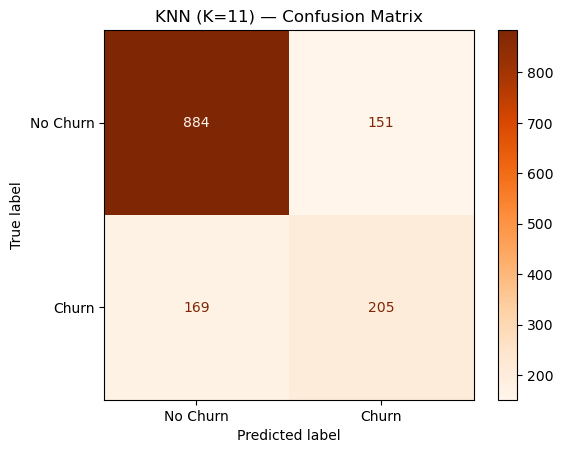

In [24]:
# Task 11  Using your chosen K, report full test-set metrics (accuracy, precision, recall, F1) and the confusion matrix for 
# your final KNN model. 
CHOSEN_K = 11

knn_final = KNeighborsClassifier(n_neighbors=CHOSEN_K)
knn_final.fit(X_train_scaled, y_train)
knn_pred_final = knn_final.predict(X_test_scaled)

print("Accuracy: ", accuracy_score(y_test, knn_pred_final))
print("Precision:", precision_score(y_test, knn_pred_final))
print("Recall:   ", recall_score(y_test, knn_pred_final))
print("F1-score: ", f1_score(y_test, knn_pred_final))

cm_knn = confusion_matrix(y_test, knn_pred_final)
print(cm_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Oranges')
plt.title(f'KNN (K={CHOSEN_K}) — Confusion Matrix')
plt.show()


In [27]:
 # Final KNN (K=11) achieved 77.3% accuracy, 57.6% precision, 54.8% recall, F1=0.562.
# The confusion matrix shows it caught 205 of 374 actual churners, with 151 false alarms —
# weaker than both the Decision Tree (F1=0.601) and Logistic Regression (F1=0.609) benchmarks.


# Part 5 — Model Comparison (4 Models) 
# Task 12 Build one comparison table: Decision Tree, Random Forest, Logistic Regression, KNN — accuracy, precision, 
# recall, F1-score for each (reuse your recorded Lab 3/4 numbers; retrain quickly if needed). 

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)  # note: RF doesn't need scaled data (tree-based)
rf_pred = rf.predict(X_test)


comparison_4models = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Decision Tree': [
        accuracy_score(y_test, dt_pred),
        precision_score(y_test, dt_pred),
        recall_score(y_test, dt_pred),
        f1_score(y_test, dt_pred)
    ],
    'Random Forest': [0.7970, 0.6507, 0.5080, 0.5706],  # from Lab 4 (tuned RF — final model chosen there)
    'Logistic Regression': [
        accuracy_score(y_test, logreg_pred),
        precision_score(y_test, logreg_pred),
        recall_score(y_test, logreg_pred),
        f1_score(y_test, logreg_pred)
    ],
    'KNN (K=11)': [
        accuracy_score(y_test, knn_pred_final),
        precision_score(y_test, knn_pred_final),
        recall_score(y_test, knn_pred_final),
        f1_score(y_test, knn_pred_final)
    ],
}).round(4)

print(comparison_4models.to_string(index=False))

   Metric  Decision Tree  Random Forest  Logistic Regression  KNN (K=11)
 Accuracy         0.7942         0.7970               0.8070      0.7729
Precision         0.6193         0.6507               0.6584      0.5758
   Recall         0.5829         0.5080               0.5668      0.5481
 F1-score         0.6006         0.5706               0.6092      0.5616


In [28]:
# This table compares all four models (Decision Tree, Random Forest, Logistic Regression, KNN) trained across this course 
# on the same test set — Decision Tree and Random Forest are tree-based (unscaled), while Logistic Regression and KNN needed 
# scaled data — allowing a fair comparison across all four algorithm types.

# Task 13  Which model performs best overall? Does the ranking change depending on which metric you prioritize (e.g. 
# precision vs. recall)? Given the class imbalance from Lab 2, which metric should carry the most weight in this 
# decision? 
# Answer: Logistic Regression is the best overall — highest accuracy, precision, and F1. Decision 
# Tree has the best recall though (catches more churners). Since class imbalance makes recall/F1 most important, and Logistic 
# Regression wins on F1 (0.609), it's the top model — but Decision Tree is worth considering if catching churners matters more
# than precision.

In [29]:
# Part 6 — Coefficient Interpretation
# Task 14  Extract the coefficients and build a table: Feature | Coefficient | Odds Ratio (exp(coefficient)) | Interpretation. 
# Interpret at least 4 features (e.g. "customers on this contract type have roughly ___× the odds of churning, 
# holding other features constant"). 
coef_table = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logreg.coef_[0],
    'Odds Ratio': np.exp(logreg.coef_[0])
}).sort_values('Odds Ratio', ascending=False)

print(coef_table.to_string(index=False))

                              Feature  Coefficient  Odds Ratio
          InternetService_Fiber optic     0.776154    2.173099
                         TotalCharges     0.514285    1.672442
                  StreamingMovies_Yes     0.257227    1.293338
                      StreamingTV_Yes     0.257144    1.293231
                    MultipleLines_Yes     0.216167    1.241310
                 PaperlessBilling_Yes     0.182034    1.199655
       PaymentMethod_Electronic check     0.181103    1.198539
                        SeniorCitizen     0.053073    1.054507
                 DeviceProtection_Yes     0.053048    1.054480
           PaymentMethod_Mailed check     0.032262    1.032788
                          gender_Male     0.011094    1.011156
                          Partner_Yes     0.010866    1.010926
                     PhoneService_Yes     0.006794    1.006817
       MultipleLines_No phone service    -0.006794    0.993229
                     OnlineBackup_Yes    -0.012022    0

In [30]:
# Top 4 features:
# Fiber optic (2.17×) and high total charges (1.67×) raise churn odds most. Long tenure (0.29×) and two-year 
# contracts (0.56×) lower it most — the strongest factors against churn.


In [31]:
# Task 15  Do the features with the largest effect here agree with what Lab 2's EDA and Lab 3's Decision Tree feature 
# importances suggested? Note any disagreements. 
# Answer: Yes, largely agree — tenure and Fiber optic internet were the top features in both Lab 3's Decision Tree and here, 
# confirming they're genuinely important. One disagreement: Contract_Two year and TotalCharges show up more strongly 
# here than in the Decision Tree, likely because Logistic Regression captures linear/additive effects across all features, 
# while the tree concentrated almost all importance on just the top 1-2 splits.

In [32]:
# Part 7 — Final Model Selection & Conclusion 
# Task 16  Select your final model from all four candidates and justify the choice in 2–3 sentences, referencing your Part 5 
# comparison table and Lab 4's cross-validation lesson about not trusting a single number too much. 
# Answer: I chose Logistic Regression — it led on accuracy, precision, and F1 in the comparison table. But per Lab 4's
# lesson, a single split isn't fully trustworthy — cross-validation should confirm this before fully committing, especially 
# since Decision Tree still has better recall.

In [33]:
# Task 17 Write a short conclusion (5–7 sentences): how does today's best model compare to Labs 3–4's best model? 
# What did feature scaling change? What are the remaining limitations of your best model, and what would you try next?
# Answer: Logistic Regression (F1=0.609) slightly beat the Decision Tree (F1=0.601) and clearly beat Random Forest and KNN. 
# Scaling mattered for Logistic Regression and KNN, but not for the tree models. Its strength is interpretability — odds ratios
# confirmed tenure, contract length, and internet type as key churn drivers. But it still misses over 40% of churners and assumes 
# linear relationships. Next steps: cross-validate this result, try class_weight='balanced' for better recall, and test Gradient 
# Boosting.